<a href="https://colab.research.google.com/github/Noory6m/Image-Processing/blob/main/Lab3_Image_Mnupilations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
# Import the library
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt


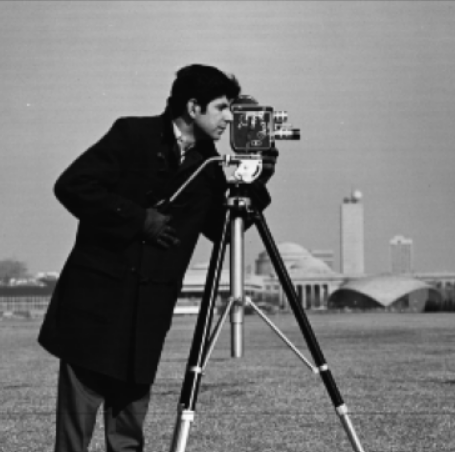

In [2]:
# ── Load image ────────────────────────────────────

img = Image.open('/Screenshot 2026-08-27 175711.png').convert('L')
img

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
width, height = img.size

# Scaling factors
scale_x = 2
scale_y = 2

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────
# Resize the image using PIL's built-in method
new_width = int(width * scale_x)
new_height = int(height * scale_y)

scaled_img = img.resize((new_width, new_height), resample=Image.Resampling.LANCZOS)



In [5]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")
print(f"Original size: {img.size}")
print(f"Scaled size:   {scaled_img.size}")


Original size: (455, 452)
Scaled size:   (910, 904)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
# Non-uniform scale: stretch horizontally only
cx, cy = 2, 1
non_uniform_size = (int(width * cx), int(height * cy))
stretched_img = img.resize(non_uniform_size, resample=Image.Resampling.LANCZOS)

In [7]:
# Save and verify
stretched_img.save("task1_1_stretched.jpg")
print(f"Stretched size: {stretched_img.size}")

Stretched size: (910, 452)


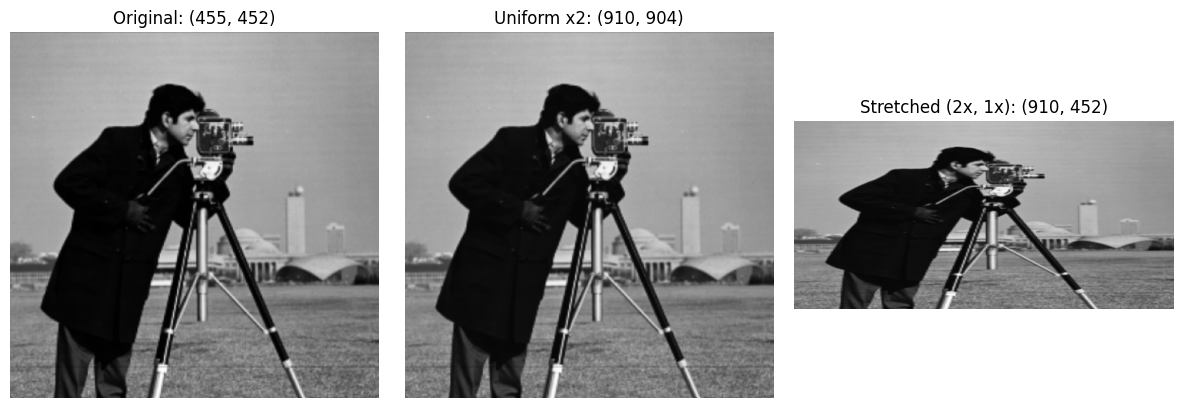

In [8]:
# Display comparison
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img, cmap='gray')
ax[0].set_title(f"Original: {img.size}")
ax[0].axis('off')

ax[1].imshow(scaled_img, cmap='gray')
ax[1].set_title(f"Uniform x2: {scaled_img.size}")
ax[1].axis('off')

ax[2].imshow(stretched_img, cmap='gray')
ax[2].set_title(f"Stretched (2x, 1x): {stretched_img.size}")
ax[2].axis('off')
plt.tight_layout()
plt.show()

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (455, 452)
Rotated size:  (619, 622)


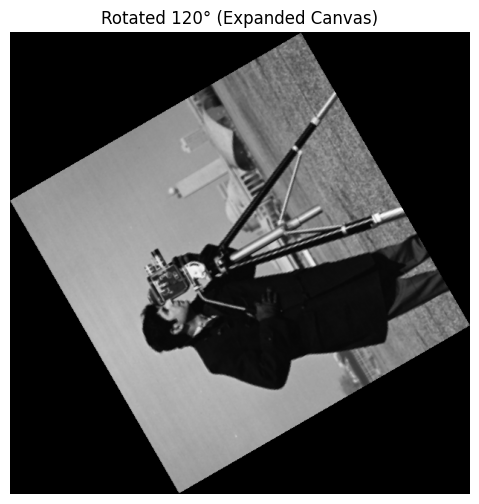

In [9]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Rotate with expand=True to resize canvas and fit the entire rotated image
rotated_img = img.rotate(120, resample=Image.Resampling.BICUBIC, expand=True)

# Save the rotated image and print the sizes
rotated_img.save("task1_2_rotated.jpg")
print(f"Original size: {img.size}")
print(f"Rotated size:  {rotated_img.size}")

# Display
plt.figure(figsize=(6, 6))
plt.imshow(rotated_img, cmap='gray')
plt.title("Rotated 120° (Expanded Canvas)")
plt.axis('off')
plt.show()


### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size


In [11]:
# -- d. define the shear matrix ──────────────────────────
# Horizontal shear factor (slant along X-axis)
m = 0.5

# Forward shear expands width to: width + m * height
new_width = int(width + abs(m) * height)
new_height = height

# Inverse affine matrix [a, b, c, d, e, f]:
# x_in = 1*x_out + (-m)*y_out + 0
# y_in = 0*x_out + 1*y_out + 0
shear_matrix = (1, -m, 0, 0, 1, 0)


In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC
)

Sheared image size: (681, 452)


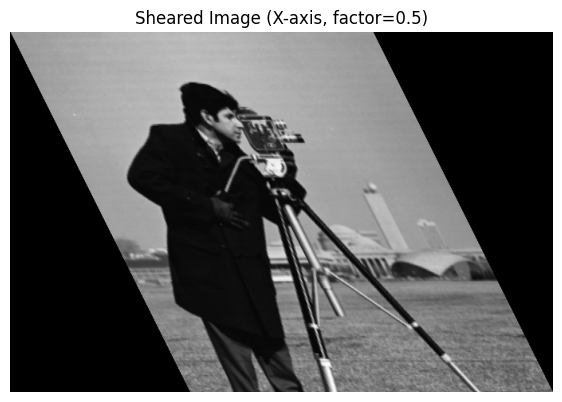

In [13]:
# -- f. Save the sheared image (The new image name should be "task1_3_sheared.jpg")
sheared_img.save("task1_3_sheared.jpg")
print(f"Sheared image size: {sheared_img.size}")

plt.figure(figsize=(7, 5))
plt.imshow(sheared_img, cmap='gray')
plt.title(f"Sheared Image (X-axis, factor={m})")
plt.axis('off')
plt.show()

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

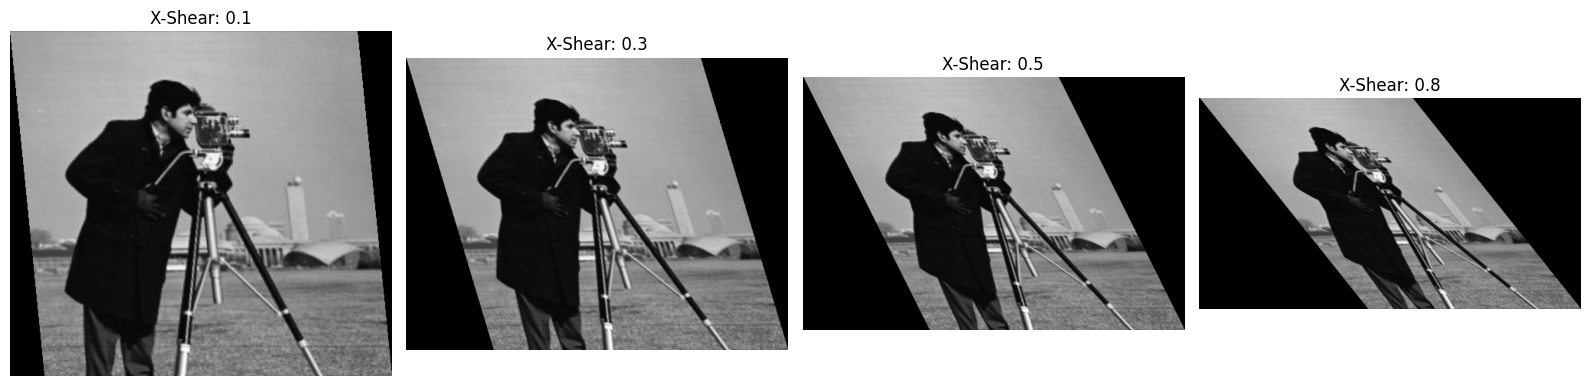

In [14]:
# Compare multiple shear configurations
shear_factors = [0.1, 0.3, 0.5, 0.8]
fig, axes = plt.subplots(1, len(shear_factors), figsize=(16, 4))

for ax, sh in zip(axes, shear_factors):
    nw = int(width + sh * height)
    matrix = (1, -sh, 0, 0, 1, 0)
    res = img.transform((nw, height), Image.Transform.AFFINE, matrix, resample=Image.Resampling.BILINEAR)
    ax.imshow(res, cmap='gray')
    ax.set_title(f"X-Shear: {sh}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Intensity Transformations
Negative · Log · Power Law (Gamma)

In [15]:
# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
arr = np.array(img, dtype=np.uint8)
negative_arr = 255 - arr
negative_img_np = Image.fromarray(negative_arr)
negative_img_np.save("task2_1_negative_np.jpg")



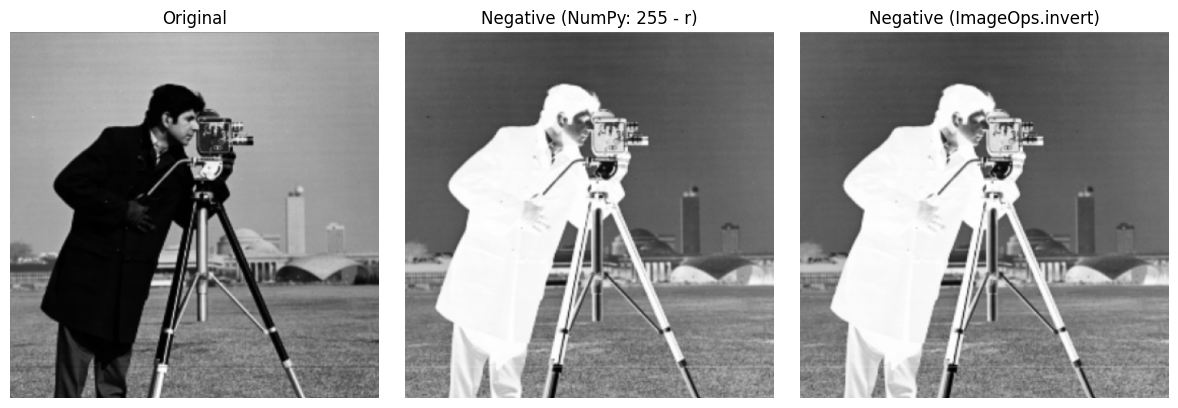

In [16]:
# Method 2: PIL's ImageOps
negative_img_ops = ImageOps.invert(img)
negative_img_ops.save("task2_1_negative_ops.jpg")

# Display comparison
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img, cmap='gray')
ax[0].set_title("Original")
ax[0].axis('off')

ax[1].imshow(negative_img_np, cmap='gray')
ax[1].set_title("Negative (NumPy: 255 - r)")
ax[1].axis('off')

ax[2].imshow(negative_img_ops, cmap='gray')
ax[2].set_title("Negative (ImageOps.invert)")
ax[2].axis('off')
plt.tight_layout()
plt.show()

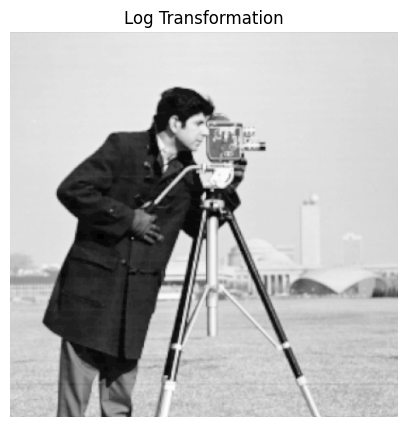

In [17]:
# ── 2. Log transformation ──────────────────────────

# Scaling constant: c = 255 / log(1 + 255)
c = 255.0 / np.log(1.0 + 255.0)

# Convert to float32 to prevent numerical issues and warnings
arr_float = np.array(img, dtype=np.float32)

# Apply log transformation
log_transformed = c * np.log(1.0 + arr_float)

# Clip to [0, 255] and cast to uint8
log_transformed_img = Image.fromarray(np.clip(log_transformed, 0, 255).astype(np.uint8))
log_transformed_img.save("task2_2_log.jpg")

plt.figure(figsize=(5, 5))
plt.imshow(log_transformed_img, cmap='gray')
plt.title("Log Transformation")
plt.axis('off')
plt.show()


<>:16: SyntaxWarning: invalid escape sequence '\g'
<>:16: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_1542/987592900.py:16: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"$\gamma = {g}$" + (" (Brighter)" if g < 1 else " (Darker)" if g > 1 else " (Identity)"))


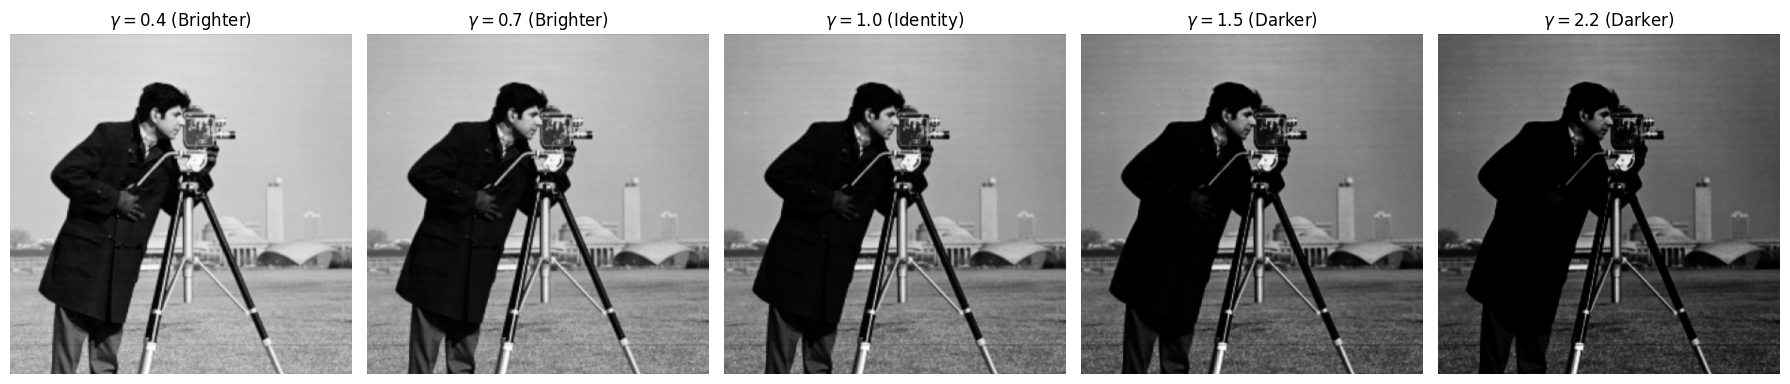

In [18]:
# ── 3. Power-law / Gamma correction ───────────────
def apply_gamma(image, gamma):
    # Normalize pixel values to range [0, 1]
    norm_arr = np.array(image, dtype=np.float32) / 255.0
    # Apply power-law formula
    gamma_arr = np.power(norm_arr, gamma) * 255.0
    return Image.fromarray(np.clip(gamma_arr, 0, 255).astype(np.uint8))

gamma_values = [0.4, 0.7, 1.0, 1.5, 2.2]
fig, axes = plt.subplots(1, len(gamma_values), figsize=(18, 4))

for ax, g in zip(axes, gamma_values):
    g_img = apply_gamma(img, g)
    g_img.save(f"task2_3_gamma_{g}.jpg")
    ax.imshow(g_img, cmap='gray')
    ax.set_title(f"$\gamma = {g}$" + (" (Brighter)" if g < 1 else " (Darker)" if g > 1 else " (Identity)"))
    ax.axis('off')

plt.tight_layout()
plt.show()